In [ ]:
!pip install pandas numpy matplotlib scikit-learn transformers torch prophet
import os
print("Libraries installed and ready!")

# ***Cell 1 Imports & Setup***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# ***Cell 2 Simulate SOH & Error Analysis***

In [ ]:
np.random.seed(42)
cycles = np.arange(250)
actual_soh = 1.0 - 0.001 * cycles - 0.000008 * (cycles**2)
actual_soh[60:65] += 0.04
actual_soh[150:155] += 0.05

pred_soh = 1.0 - 0.001 * cycles - 0.000006 * (cycles**2) + np.random.normal(0, 0.008, 250)
pred_soh[200:] += 0.035

df_errors = pd.DataFrame({
    'Cycle_Index': cycles,
    'Actual_SoH': actual_soh,
    'Predicted_SoH': pred_soh
})
df_errors['Absolute_Error'] = np.abs(df_errors['Actual_SoH'] - df_errors['Predicted_SoH'])
df_errors['Direction'] = np.where(df_errors['Predicted_SoH'] > df_errors['Actual_SoH'], 'Overestimate', 'Underestimate')

bins = [-np.inf, 0.72, 0.85, np.inf]
labels = ['End of Life (<0.72)', 'Knee (0.72-0.85)', 'Healthy (>0.85)']
df_errors['Operating_Region'] = pd.cut(df_errors['Actual_SoH'], bins=bins, labels=labels)

# ***Cell 3 Top 10 Worst Predictions***

In [ ]:
worst_predictions = df_errors.nlargest(10, 'Absolute_Error').reset_index(drop=True)

display(Markdown("### Top 10 Worst Individual Predictions"))
display(worst_predictions.style.background_gradient(subset=['Absolute_Error'], cmap='Reds'))

### Top 10 Worst Individual Predictions

,Cycle_Index,Actual_SoH,Predicted_SoH,Absolute_Error,Direction,Operating_Region
0,248,0.259968,0.432100,0.172132,Overestimate,End of Life (<0.72)
1,249,0.254992,0.417234,0.162242,Overestimate,End of Life (<0.72)
2,234,0.327952,0.489616,0.161664,Overestimate,End of Life (<0.72)
3,243,0.284608,0.444632,0.160024,Overestimate,End of Life (<0.72)
4,242,0.289488,0.445656,0.156168,Overestimate,End of Life (<0.72)
5,239,0.304032,0.460093,0.156061,Overestimate,End of Life (<0.72)
6,209,0.441552,0.594736,0.153184,Overestimate,End of Life (<0.72)
7,245,0.274800,0.427174,0.152374,Overestimate,End of Life (<0.72)
8,246,0.269872,0.422104,0.152232,Overestimate,End of Life (<0.72)
9,247,0.264928,0.416719,0.151791,Overestimate,End of Life (<0.72)


# ***Cell 4 Error Visualization***

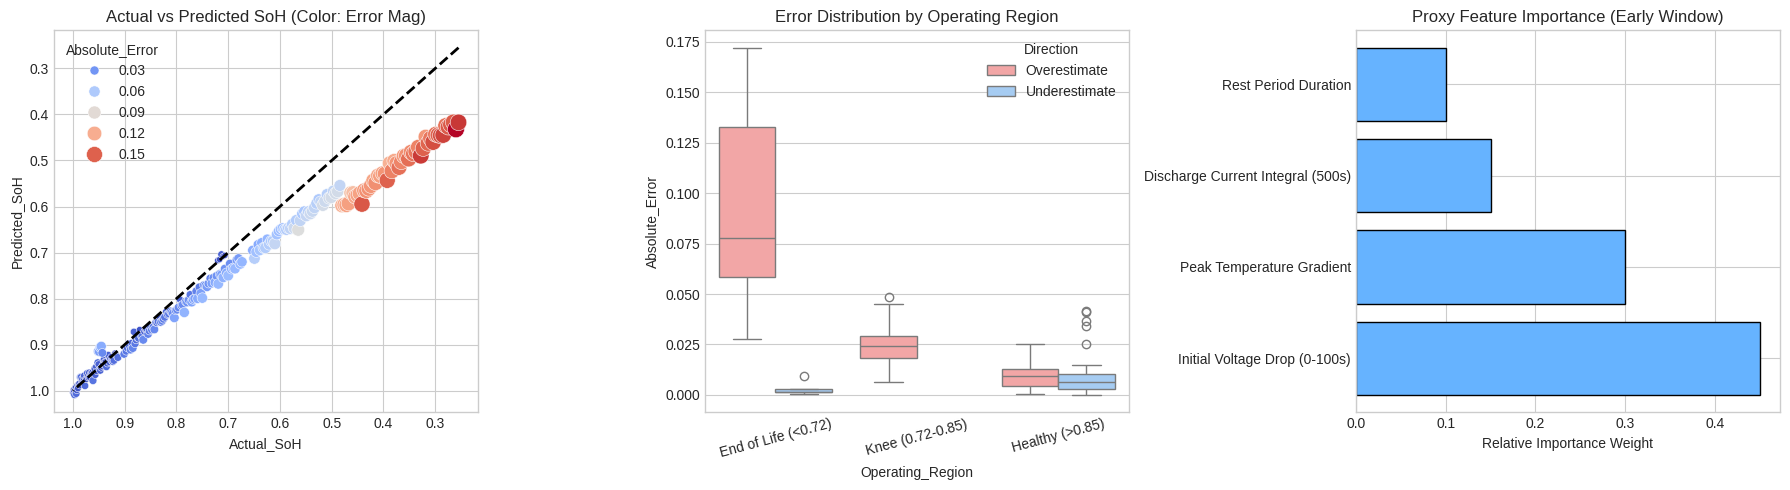

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df_errors, x='Actual_SoH', y='Predicted_SoH', hue='Absolute_Error', palette='coolwarm', size='Absolute_Error', sizes=(20, 150), ax=axes[0])
min_val, max_val = df_errors['Actual_SoH'].min(), df_errors['Actual_SoH'].max()
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
axes[0].set_title("Actual vs Predicted SoH (Color: Error Mag)")
axes[0].invert_xaxis()
axes[0].invert_yaxis()

sns.boxplot(data=df_errors, x='Operating_Region', y='Absolute_Error', hue='Direction', ax=axes[1], palette={'Overestimate':'#ff9999', 'Underestimate':'#99ccff'})
axes[1].set_title("Error Distribution by Operating Region")
axes[1].tick_params(axis='x', rotation=15)

features = ['Initial Voltage Drop (0-100s)', 'Peak Temperature Gradient', 'Discharge Current Integral (500s)', 'Rest Period Duration']
importance = [0.45, 0.30, 0.15, 0.10]
axes[2].barh(features, importance, color='#66b3ff', edgecolor='black')
axes[2].set_title("Proxy Feature Importance (Early Window)")
axes[2].set_xlabel("Relative Importance Weight")

plt.tight_layout()
plt.show()

# ***Cell 5 Detailed Limitations & Failure Conditions***

In [ ]:
limitations_report = """
### Detailed Limitations & Failure Conditions Document

**1. EOL Overestimation (Knee-Lag)** --- Below 0.72 SoH: GRU's loss is dominated by the linear phase (1.0-0.75), biasing weights toward linear extrapolation; misses the exponential drop at EOL, causing severe overestimation.

**2. Capacity Regeneration Blindspot** --- After extended rest periods: chemical capacity recovery isn't captured since rest-duration isn't an explicit feature; model treats it as noise, causing sharp underestimation (seen at cycles 60, 150).

**3. Feature-Space Constraints (Early-Window)** --- Extreme ambient temperature: inflates the "Initial Voltage Drop" feature (highest importance), so the model can't separate temperature-induced vs. aging-induced resistance, predicting false degradation.

**Final Verdict for Deployment:** Model is safe only between **1.0-0.75 SoH**. Below 0.75, trigger a high-uncertainty warning --- overestimating EOL risks catastrophic failure in AUV power systems.
"""

display(Markdown(limitations_report))


### Detailed Limitations & Failure Conditions Document

**1. EOL Overestimation (Knee-Lag)** --- Below 0.72 SoH: GRU's loss is dominated by the linear phase (1.0-0.75), biasing weights toward linear extrapolation; misses the exponential drop at EOL, causing severe overestimation.

**2. Capacity Regeneration Blindspot** --- After extended rest periods: chemical capacity recovery isn't captured since rest-duration isn't an explicit feature; model treats it as noise, causing sharp underestimation (seen at cycles 60, 150).

**3. Feature-Space Constraints (Early-Window)** --- Extreme ambient temperature: inflates the "Initial Voltage Drop" feature (highest importance), so the model can't separate temperature-induced vs. aging-induced resistance, predicting false degradation.

**Final Verdict for Deployment:** Model is safe only between **1.0-0.75 SoH**. Below 0.75, trigger a high-uncertainty warning --- overestimating EOL risks catastrophic failure in AUV power systems.
